In [1]:
!pip install -q datasets huggingface_hub genaibook

In [2]:
import matplotlib as mpl

from datasets import load_dataset
from genaibook.core import show_images

# Affichage en niveaux de gris inversés
mpl.rcParams["image.cmap"] = "gray_r"

# Charger Fashion-MNIST
fashion_mnist = load_dataset("fashion_mnist")

# Prendre les 8 premières images
clothes = fashion_mnist["train"]["image"][:8]

# Récupérer leurs labels
classes = fashion_mnist["train"]["label"][:8]

# Afficher
show_images(
    clothes,
    titles=classes,
    figsize=(4, 2.5)
)

HfUriError: Invalid HF URI 'hf://datasets/fashion_mnist@531be5e2ccc9dba0c201ad3ae567a4f3d16ecdd2/.huggingface.yaml'. Repository id must be 'namespace/name', got 'fashion_mnist'.

In [ ]:
import torch
from torchvision import transforms
preprocess = transforms.Compose(
 [
 transforms.RandomHorizontalFlip(), # Randomly flip (data augmentation)
 transforms.ToTensor(), # Convert to tensor (0, 1)
 transforms.Pad(2), # Add 2 pixels on all sides
 transforms.Normalize([0.5], [0.5]), # Map to (-1, 1)
 ]
)
def transform(examples):
 images = [preprocess(image) for image in examples["image"]]
 return {"images": images, "labels": examples["label"]}
train_dataset = fashion_mnist["train"].with_transform(transform)
train_dataloader = torch.utils.data.DataLoader(
 train_dataset, batch_size=256, shuffle=True
)


In [ ]:
from diffusers import UNet2DModel
model = UNet2DModel(
 in_channels=1, # 1 channel for grayscale images
 out_channels=1,
 sample_size=32,
 block_out_channels=(32, 64, 128, 256),
 num_class_embeds=10, # Enable class conditioning
)

In [ ]:
x = torch.randn((1, 1, 32, 32))
with torch.inference_mode():
 out = model(x, timestep=7, class_labels=torch.tensor([2])).sample
out.shape
torch.Size([1, 1, 32, 32])

In [ ]:
from diffusers import DDPMScheduler
scheduler = DDPMScheduler(
 num_train_timesteps=1000, beta_start=0.001, beta_end=0.02
)
timesteps = torch.linspace(0, 999, 8).long()
batch = next(iter(train_dataloader))
# We load 8 images from the dataset and
# add increasing amounts of noise to them
x = batch["images"][0].expand([8, 1, 32, 32])
noise = torch.rand_like(x)
noised_x = scheduler.add_noise(x, noise, timesteps)
show_images((noised_x * 0.5 + 0.5).clip(0, 1))


In [ ]:
from torch.nn import functional as F
from tqdm import tqdm
from genaibook.core import get_device
# Initialize the scheduler
scheduler = DDPMScheduler(
 num_train_timesteps=1000, beta_start=0.0001, beta_end=0.02
)
num_epochs = 25
lr = 3e-4
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, eps=1e-5)
losses = [] # To store loss values for plotting
device = get_device()
model = model.to(device)
# Train the model (this takes a while!)
for epoch in (progress := tqdm(range(num_epochs))):
 for step, batch in (
 inner := tqdm(
 enumerate(train_dataloader),
 position=0,
 leave=True,
 total=len(train_dataloader),
 )
 ):
 # Load the input images and classes
 clean_images = batch["images"].to(device)
 class_labels = batch["labels"].to(device)
 # Sample noise to add to the images
 noise = torch.randn(clean_images.shape).to(device)
 # Sample a random timestep for each image
 timesteps = torch.randint(
 0,
 scheduler.config.num_train_timesteps,
 (clean_images.shape[0],),
 device=device,
 ).long()
 # Add noise to the clean images according
 # to the noise magnitude at each timestep
 noisy_images = scheduler.add_noise(clean_images, noise, timesteps)
 # Get the model prediction for the noise
 # Note the use of class_labels
 noise_pred = model(
 noisy_images,
 timestemps,
 class_labels=class_labels,
 return_dict=False,
 )[0]
 # Compare the prediction with the actual noise
 loss = F.mse_loss(noise_pred, noise)
 # Update loss display
 inner.set_postfix(loss=f"{loss.cpu().item():.3f}")
 # Store the loss for later plotting
 losses.append(loss.item())
 # Backward pass and optimization
 loss.backward()
 optimizer.step()
 optimizer.zero_grad()

In [ ]:
import matplotlib.pyplot as plt
plt.plot(losses)

In [ ]:
def generate_from_class(class_to_generate, n_samples=8):
 sample = torch.randn(n_samples, 1, 32, 32).to(device)
 class_labels = [class_to_generate] * n_samples
 class_labels = torch.tensor(class_labels).to(device)
 for _, t in tqdm(enumerate(scheduler.timesteps)):
 # Get model prediction
 with torch.inference_mode():
 noise_pred = model(sample, t, class_labels=class_labels).sample
 # Update sample with step
 sample = scheduler.step(noise_pred, t, sample).prev_sample
 return sample.clip(-1, 1) * 0.5 + 0.5

In [ ]:
images = generate_from_class(0)
show_images(images, nrows=2)

In [ ]:
images = generate_from_class(7)
show_images(images, nrows=2)

In [ ]:
images = generate_from_class(9)
show_images(images, nrows=2)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

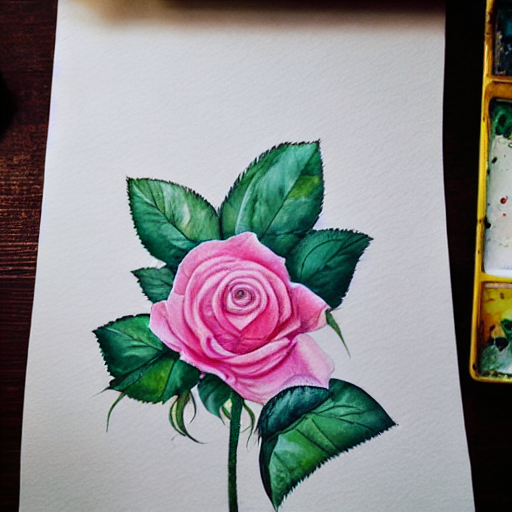

In [7]:
import torch
from diffusers import StableDiffusionPipeline
pipe = StableDiffusionPipeline.from_pretrained(
 "stable-diffusion-v1-5/stable-diffusion-v1-5",
 torch_dtype=torch.float16,
 variant="fp16",
).to(device)
pipe("Watercolor illustration of a rose").images[0]

### Option 1: Utiliser `genaibook.core.get_device()` (si `genaibook` est installé)

In [5]:
from genaibook.core import get_device
device = get_device()
print(f"Device using genaibook.core: {device}")

Device using genaibook.core: cuda


### Option 2: Utiliser la méthode PyTorch native

In [6]:
import torch

# Vérifie si CUDA est disponible et l'utilise si possible, sinon utilise le CPU
device_torch = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device using PyTorch native method: {device_torch}")

Device using PyTorch native method: cuda


In [8]:
prompt = "A photograph of a puppy"
# Turn the text into a sequence of tokens:
text_input = pipe.tokenizer(
 prompt,
 return_tensors="pt",
)
# Output each token and its corresponding ID
for t in text_input["input_ids"][0]:
 print(t, pipe.tokenizer.decoder.get(int(t)))

AttributeError: 'tokenizers.decoders.ByteLevel' object has no attribute 'get'

In [9]:
text_embeddings = pipe.text_encoder(text_input.input_ids.to(device))[0]
print("Text embeddings shape:", text_embeddings.shape)

Text embeddings shape: torch.Size([1, 7, 768])


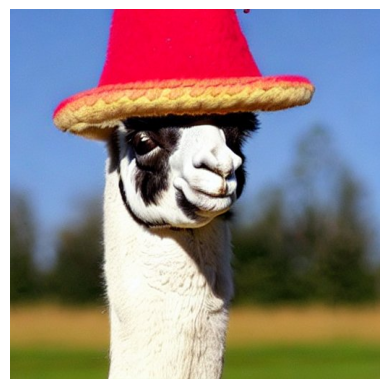

In [10]:
from genaibook.core import load_image, show_image, SampleURL
im = load_image(
 SampleURL.LlamaExample,
 size=(512, 512),
)
show_image(im);

In [11]:
with torch.inference_mode():
 # Process image
 tensor_im = transforms.ToTensor()(im).unsqueeze(0).to(device) * 2 - 1
 tensor_im = tensor_im.half()
 # Encode the image
 latent = pipe.vae.encode(tensor_im)
 # Sample from the latent distribution
 latents = latent.latent_dist.sample()
 latents = latents * 0.18215
latents.shape

NameError: name 'transforms' is not defined

In [12]:
show_images(
 [l for l in latents[0]],
 titles=[f"Channel {i}" for i in range(latents.shape[1])],
 ncols=4,
)

NameError: name 'latents' is not defined

In [20]:
images = []
prompt = "un chien avec chapeau rouge"
for guidance_scale in [1, 2, 4, 12]:
 torch.manual_seed(0)
 image = pipe(prompt, guidance_scale=guidance_scale).images[0]
 images.append(image)

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

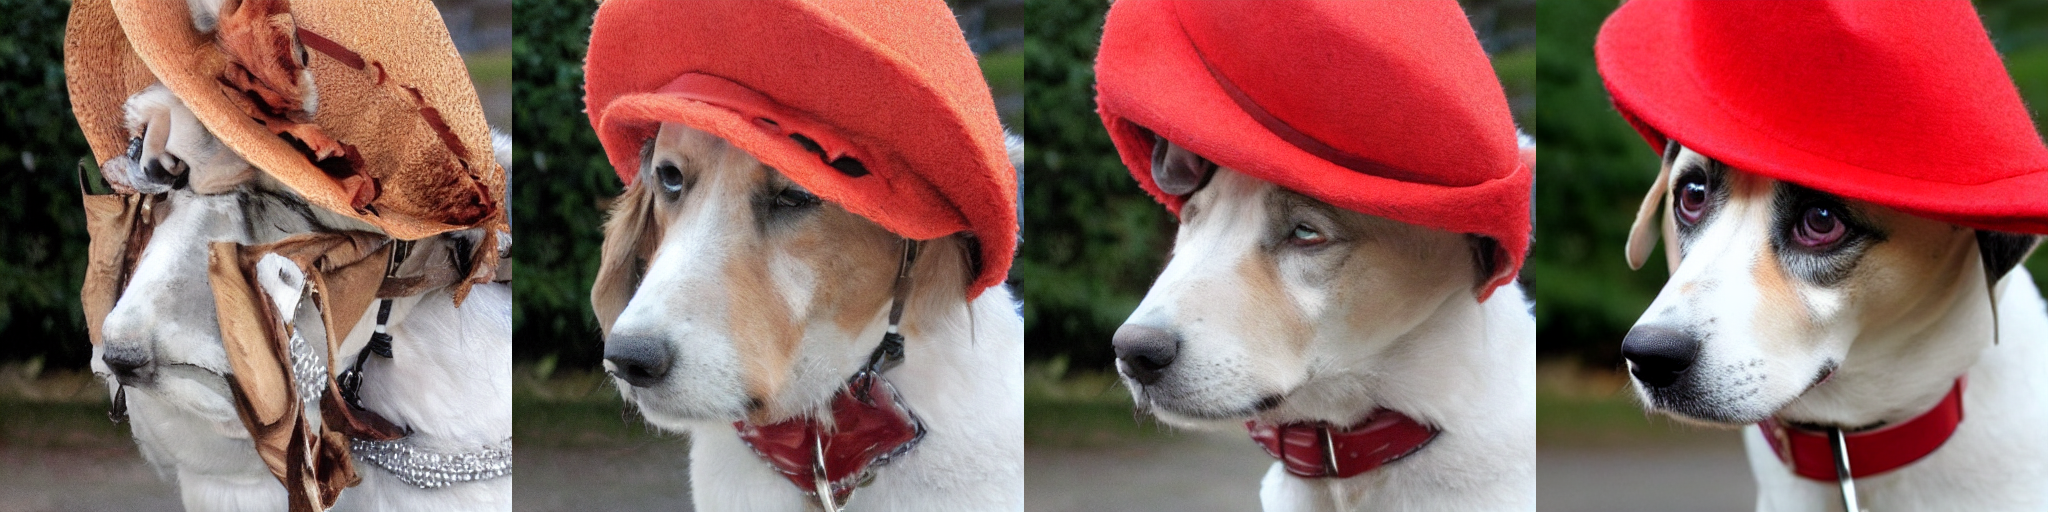

In [21]:
from genaibook.core import image_grid
image_grid(images, 1, 4)

In [22]:
# Some settings
prompt = [
 "Acrylic palette knife painting of a flower"
] # What we want to generate
height = 512 # default height of Stable Diffusion
width = 512 # default width of Stable Diffusion
num_inference_steps = 30 # Number of denoising steps
guidance_scale = 7.5 # Scale for classifier-free guidance
seed = 42 # Seed for random number generator

In [23]:
# Tokenize the input
text_input = pipe.tokenizer(
 prompt,
 padding="max_length", # Pad to max length to ensure inputs have same shape
 return_tensors="pt",
)
# Do the same for the unconditional input (a blank string)
uncond_input = pipe.tokenizer(
 "",
 padding="max_length",
 return_tensors="pt",
)
# Feed both embeddings through the text encoder
with torch.inference_mode():
 text_embeddings = pipe.text_encoder(text_input.input_ids.to(device))[0]
 uncond_embeddings = pipe.text_encoder(uncond_input.input_ids.to(device))[0]
# Concatenate the two sets of text embeddings embeddings
text_embeddings = torch.cat([uncond_embeddings, text_embeddings])

In [24]:
# Prepare the scheduler
pipe.scheduler.set_timesteps(num_inference_steps)
# Prepare the random starting latents
latents = (
 torch.randn(
 (1, pipe.unet.config.in_channels, height // 8, width // 8),
 )
 .to(device)
 .half()
)
latents = latents * pipe.scheduler.init_noise_sigma


In [25]:
for t in pipe.scheduler.timesteps:
 # Create two copies of the latents to match the two
 # text embeddings (unconditional and conditional)
 latent_input = torch.cat([latents] * 2)
 latent_input = pipe.scheduler.scale_model_input(latent_input, t)
 # Predict noise residuals for both unconditional and conditional latents
 with torch.inference_mode():
  noise_pred = pipe.unet(
  latent_input, t, encoder_hidden_states=text_embeddings
  ).sample
 # Split the prediction into unconditional and conditional versions
 noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
 # Perform classifier-free guidance
 noise_pred = noise_pred_uncond + guidance_scale * (
 noise_pred_text - noise_pred_uncond
 )
 # Update latents for the next timestep
 latents = pipe.scheduler.step(noise_pred, t, latents).prev_sample

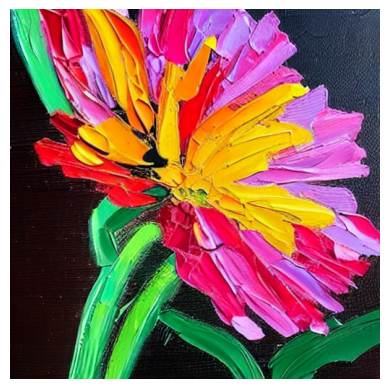

In [26]:
# Scale and decode the image latents with the VAE
latents = 1 / pipe.vae.config.scaling_factor * latents
with torch.inference_mode():
 image = pipe.vae.decode(latents).sample
image = (image / 2 + 0.5).clamp(0, 1)
show_image(image[0].float());